In [1]:
import sys
print(sys.executable)


/usr/local/bin/python3


In [1]:
import os
import cv2
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import keras
import tensorflow

from tensorflow.keras.models import Model
from tensorflow.keras.utils import plot_model
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import VGG19
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Input, Lambda, Dense, Flatten, Dropout, BatchNormalization, Activation

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, recall_score, precision_score, f1_score

In [2]:
train_path = '/Users/admin/Documents/IOT/input Dataset/ear drum/train_data'
test_path = '/Users/admin/Documents/IOT/input Dataset/ear drum/test_data'
val_path = '/Users/admin/Documents/IOT/input Dataset/ear drum/vali_data'

OtitExterna


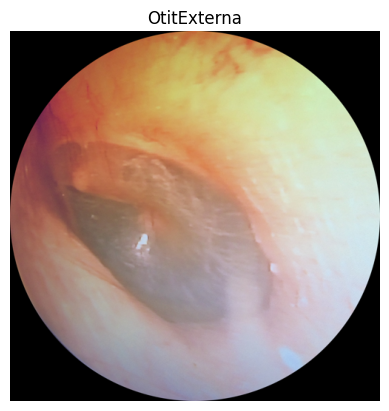

tympanoskleros


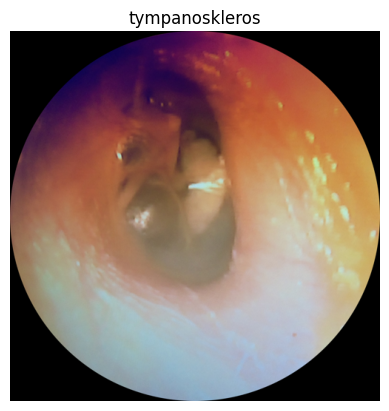

Aom


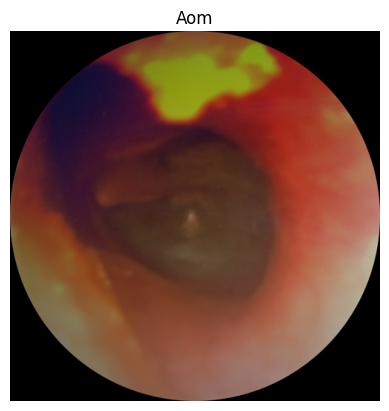

OME


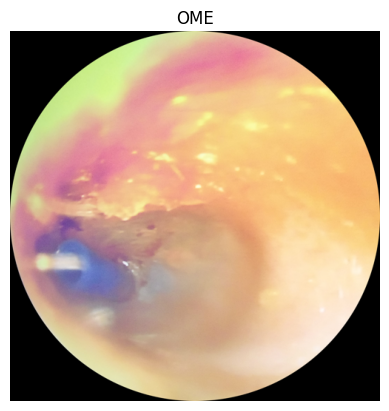

Earwax


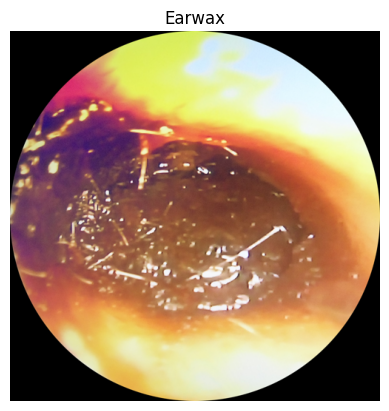

PseduoMembran


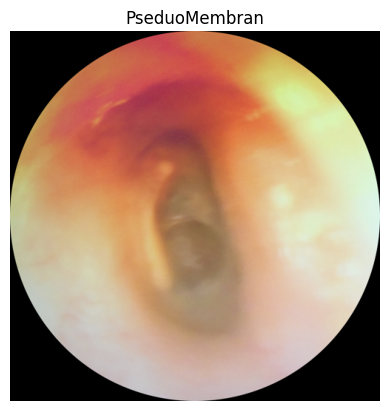

Normal


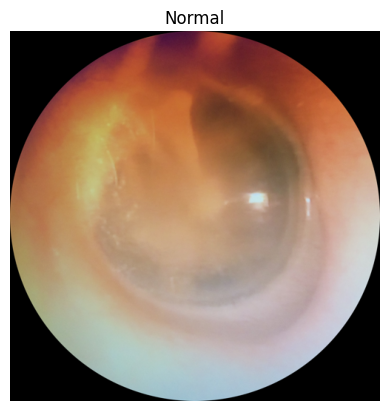

Foreign


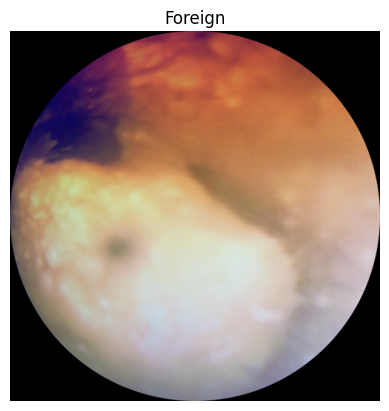

Chornic


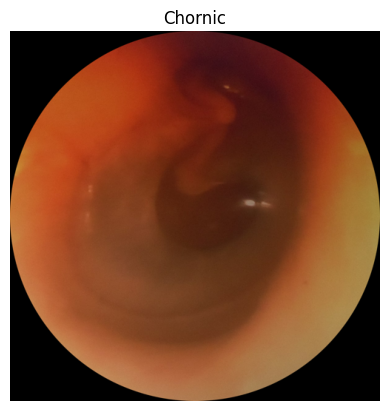

In [3]:
for folder in os.listdir(train_path):
    sub_path = os.path.join(train_path, folder)

    # Skip hidden files like .DS_Store
    if folder.startswith("."):
        continue

    print(folder)
    files = [f for f in os.listdir(sub_path) if not f.startswith(".")]  # filter hidden files

    if len(files) > 1:  # make sure at least 2 files exist
        temp_path = os.path.join(sub_path, files[1])
        img = mpimg.imread(temp_path)
        plt.imshow(img)
        plt.title(folder)  # show folder name as title
        plt.axis("off")
        plt.show()

In [4]:
def imagearray(path, size):
    data = []
    for folder in os.listdir(path):
        sub_path=path+"/"+folder

        for img in os.listdir(sub_path):
            image_path=sub_path+"/"+img
            img_arr=cv2.imread(image_path)
            img_arr=cv2.resize(img_arr, size)
            data.append(img_arr)

    return data

In [5]:
def imagearray(path, size):
    data = []
    for folder in os.listdir(path):
        sub_path = os.path.join(path, folder)

        # Skip if it's not a directory (avoids .DS_Store issues)
        if not os.path.isdir(sub_path):
            continue

        for img in os.listdir(sub_path):
            image_path = os.path.join(sub_path, img)

            # Skip hidden files or non-image files
            if img.startswith('.') or not img.lower().endswith(('.png', '.jpg', '.jpeg')):
                continue

            try:
                img_arr = cv2.imread(image_path)
                if img_arr is not None:
                    img_arr = cv2.resize(img_arr, size)
                    data.append(img_arr)
            except Exception as e:
                print(f"Skipping {image_path} due to error: {e}")
    return np.array(data)



size = (250, 250)

train = imagearray(train_path, size)
test = imagearray(test_path, size)
val = imagearray(val_path, size)

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"Val shape: {val.shape}")


Train shape: (0,)
Test shape: (0,)
Val shape: (0,)


In [6]:
x_train = np.array(train)
x_test = np.array(test)
x_val = np.array(val)

In [7]:
x_train = x_train/255.0
x_test = x_test/255.0
x_val = x_val/255.0

In [8]:
def data_class(data_path, size, class_mode):
    datagen = ImageDataGenerator(rescale = 1./255)
    classes = datagen.flow_from_directory(data_path,
                                          target_size = size,
                                          batch_size = 32,
                                          class_mode = class_mode)
    return classes

In [9]:
train_class = data_class(train_path, size, 'sparse')
test_class = data_class(test_path, size, 'sparse')
val_class = data_class(val_path,size,'sparse')

Found 829 images belonging to 9 classes.
Found 393 images belonging to 9 classes.
Found 54 images belonging to 9 classes.


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/legacy/preprocessing/image.py:146: UserWarning: Using ".tiff" files with multiple bands will cause distortion. Please verify your output.
  warnings.warn(


In [10]:
y_train = train_class.classes
y_test = test_class.classes
y_val = val_class.classes

In [11]:
train_class.class_indices

{'Aom': 0,
 'Chornic': 1,
 'Earwax': 2,
 'Foreign': 3,
 'Normal': 4,
 'OME': 5,
 'OtitExterna': 6,
 'PseduoMembran': 7,
 'tympanoskleros': 8}

In [12]:
y_train.shape,y_test.shape,y_val.shape

((829,), (393,), (54,))

In [13]:
from tensorflow.keras.applications import VGG19

vgg = VGG19(input_shape=(250, 250, 3), weights='imagenet', include_top=False)



In [14]:
for layer in vgg.layers:
    layer.trainable = False

x = Flatten()(vgg.output)# turns to 1D vector
prediction = Dense(9, activation='softmax')(x)

model = Model(inputs=vgg.input, outputs=prediction)
model.summary()
model.compile(
  loss='sparse_categorical_crossentropy',
  optimizer="adam",#helps learning effeciently 
  metrics=['accuracy']
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 250, 250, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 250, 250, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 250, 250, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 125, 125, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 125, 125, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 125, 125, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 62, 62, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 62, 62, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 62, 62, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 62, 62, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 62, 62, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 31, 31, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 31, 31, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 31, 31, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 31, 31, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 31, 31, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 15, 15, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 15, 15, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 15, 15, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 15, 15, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 15, 15, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 9)              │       225,801 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,250,185 (77.25 MB)

 Trainable params: 225,801 (882.04 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

In [15]:
Early_stop = EarlyStopping(monitor = 'val_loss', mode='min', verbose = 1, patience = 10)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define paths
train_path = "/Users/admin/Documents/IOT/input Dataset/ear drum/train_data"
val_path   = "/Users/admin/Documents/IOT/input Dataset/ear drum/vali_data"
test_path  = "/Users/admin/Documents/IOT/input Dataset/ear drum/test_data"

# ImageDataGenerator for normalization
datagen = ImageDataGenerator(rescale=1./255)

# Flow from directory
train_gen = datagen.flow_from_directory(
    train_path, target_size=(250,250), batch_size=32, class_mode="categorical")

val_gen = datagen.flow_from_directory(
    val_path, target_size=(250,250), batch_size=32, class_mode="categorical")

test_gen = datagen.flow_from_directory(
    test_path, target_size=(250,250), batch_size=32, class_mode="categorical")

# Train your model directly
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",   # instead of sparse_categorical_crossentropy
    metrics=["accuracy"]
)

VGG = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=[Early_stop]
)


Found 829 images belonging to 9 classes.


Found 54 images belonging to 9 classes.
Found 393 images belonging to 9 classes.
Epoch 1/20


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


26/26 ━━━━━━━━━━━━━━━━━━━━ 308s 12s/step - accuracy: 0.5573 - loss: 2.2129 - val_accuracy: 0.2778 - val_loss: 5.4050
Epoch 2/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 312s 12s/step - accuracy: 0.6876 - loss: 1.2701 - val_accuracy: 0.2778 - val_loss: 2.5250
Epoch 3/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 310s 12s/step - accuracy: 0.7226 - loss: 0.9085 - val_accuracy: 0.3519 - val_loss: 2.2938
Epoch 4/20
15/26 ━━━━━━━━━━━━━━━━━━━━ 2:01 11s/step - accuracy: 0.7561 - loss: 0.7461

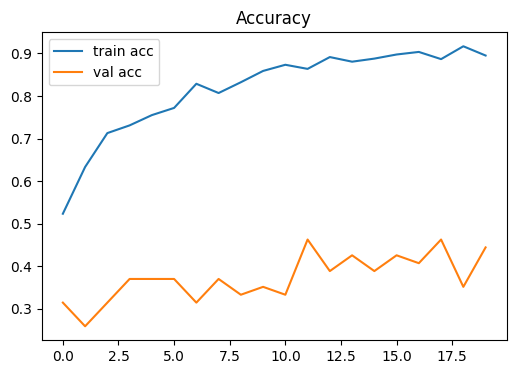

In [19]:
plt.figure(figsize=(6, 4))
plt.plot(VGG.history['accuracy'], label='train acc')
plt.plot(VGG.history['val_accuracy'], label='val acc')
plt.legend()
plt.title('Accuracy')
plt.show()

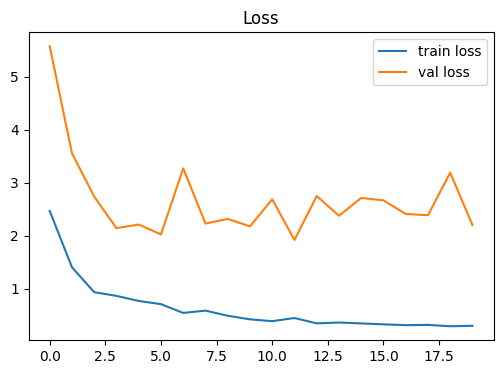

In [20]:
plt.figure(figsize=(6, 4))
plt.plot(VGG.history['loss'], label='train loss')
plt.plot(VGG.history['val_loss'], label='val loss')
plt.legend()
plt.title('Loss')
plt.show()

In [21]:
loss, acc = model.evaluate(test_gen, batch_size=32)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {acc:.4f}")


13/13 ━━━━━━━━━━━━━━━━━━━━ 137s 10s/step - accuracy: 0.9517 - loss: 0.2662
Test Loss: 0.2662
Test Accuracy: 0.9517


In [22]:
# Get predictions using the test generator
y_pred = model.predict(test_gen, verbose=1)

# Get true labels from the generator
y_true = test_gen.classes  

# Convert predictions to class labels
y_pred_classes = y_pred.argmax(axis=1)

print(y_pred_classes[:10])  # show first 10 predictions
print(y_true[:10])          # show first 10 true labels


13/13 ━━━━━━━━━━━━━━━━━━━━ 136s 10s/step
[4 7 4 4 4 4 0 8 4 4]
[4 4 4 4 4 4 4 4 4 4]


In [23]:
y_pred=np.argmax(y_pred,axis=1)


In [24]:
print(confusion_matrix(y_test,y_pred))
print('\n')

[[  0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0]
 [ 11   3 288   5  18   4  15]
 [  1   0   3   0   0   0   1]
 [  0   0  24   0   0   0   1]
 [  0   0   4   0   0   0   0]
 [  0   0  12   0   2   1   0]]




In [25]:
print('Accuracy : %.3f' %accuracy_score(y_test,y_pred))

result1 = round((accuracy_score(y_test,y_pred)),3)
result1

Accuracy : 0.733


0.733

In [26]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        12
           2       0.00      0.00      0.00         3
           4       0.84      0.87      0.85       331
           5       0.00      0.00      0.00         5
           6       0.00      0.00      0.00        20
           7       0.00      0.00      0.00         5
           8       0.00      0.00      0.00        17

    accuracy                           0.73       393
   macro avg       0.12      0.12      0.12       393
weighted avg       0.71      0.73      0.72       393



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

In [27]:
from sklearn.metrics import classification_report

# Calculate classification report including overall specificity and sensitivity
report = classification_report(y_pred,y_test, digits=4, output_dict=True)

# Extract overall specificity and sensitivity (averaged across all classes)
overall_specificity = report['macro avg']['recall']
overall_sensitivity = report['macro avg']['precision']

# Print the results
print(f"Overall Specificity: {overall_specificity:.4f}")
print(f"Overall Sensitivity: {overall_sensitivity:.4f}")

Overall Specificity: 0.1243
Overall Sensitivity: 0.1196


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

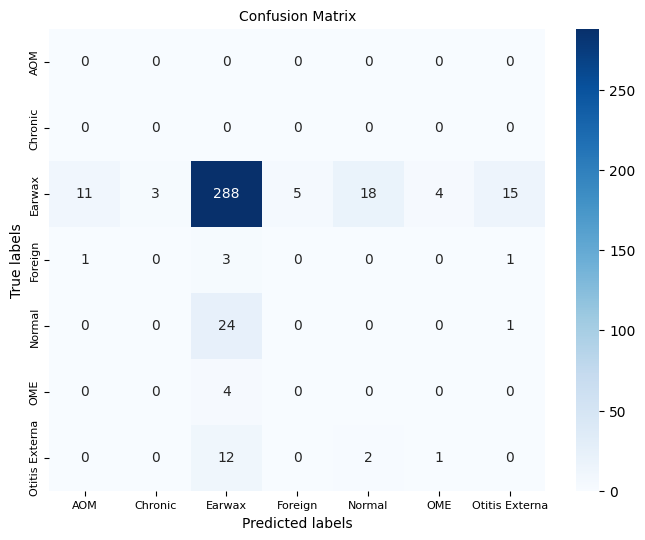

In [28]:
labels = ['AOM', 'Chronic', 'Earwax', 'Foreign', 'Normal', 'OME', 
          'Otitis Externa', 'PseudoMembrane', 'Tympanosclerosis']

conf_matrix = confusion_matrix(y_test, y_pred)   # <- note: order is (y_true, y_pred)

plt.figure(figsize=(8, 6))
ax = plt.subplot()
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap="Blues", ax=ax)

ax.set_xlabel('Predicted labels', fontsize=10)
ax.set_ylabel('True labels', fontsize=10)
ax.set_title('Confusion Matrix', fontsize=10)

# Only take as many labels as matrix size
ax.xaxis.set_ticklabels(labels[:conf_matrix.shape[0]], fontsize=8)
ax.yaxis.set_ticklabels(labels[:conf_matrix.shape[1]], fontsize=8)

plt.show()


In [ ]:
print("Matthews Correlation Coefficient (MCC):", matthews_corrcoef(y_test, y_pred))
print("Jaccard Score:", jaccard_score(y_test, y_pred, average='weighted'))
print("Hamming Loss:", hamming_loss(y_test, y_pred))

In [29]:
model.save("modelVGG19.h5")

In [30]:
# This just for the One type of Diagnose i have colleted the Data for it .
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [31]:
df= pd.read_csv('/Users/admin/Documents/IOT/input Dataset/Tympanogram/Book.csv')


In [32]:
X= df.drop(columns=['classification'], axis=1)
#X=x[:10]
y= df['classification']
#y=Y[:10]

In [33]:
X

,pressure(peak),Compilance (peak)
0,5,0.49
1,-10,0.40
2,5,0.68
3,30,0.66
4,0,0.54
5,-3,17.00
6,16,0.23
7,0,0.32
8,-35,0.39
9,125,0.25


In [34]:
y

0     A
1     A
2     A
3     A
4     A
5     C
6     C
7     C
8     C
9     C
10    C
11    c
12    C
13    A
14    A
15    A
16    A
17    A
18    A
19    A
20    A
21    A
22    A
23    A
24    A
25    A
26    A
27    A
28    A
29    A
30    A
31    A
32    A
33    A
34    A
35    A
36    A
37    A
38    A
39    A
40    A
41    A
42    B
43    B
44    B
45    B
46    B
47    C
48    C
49    B
50    B
51    A
52    A
53    B
54    B
55    A
56    A
57    B
Name: classification, dtype: object

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [36]:
rf= RandomForestClassifier(criterion='gini',n_estimators=30,random_state=25,n_jobs=5)

In [37]:
rf.fit(X_train,y_train)

prediction= rf.predict(X_test)
print('Accuracy : %.3f' %accuracy_score(y_test,prediction))

result2 = round(accuracy_score(y_test,prediction),3)
result2

Accuracy : 0.917


0.917

In [38]:
print(confusion_matrix(y_test,prediction))
print('\n')

[[8 0 1]
 [0 2 0]
 [0 0 1]]




In [39]:
print(classification_report(y_test,prediction))

              precision    recall  f1-score   support

           A       1.00      0.89      0.94         9
           B       1.00      1.00      1.00         2
           C       0.50      1.00      0.67         1

    accuracy                           0.92        12
   macro avg       0.83      0.96      0.87        12
weighted avg       0.96      0.92      0.93        12



In [40]:

from sklearn.metrics import classification_report

# Calculate classification report including overall specificity and sensitivity
report = classification_report(y_test,prediction, digits=4, output_dict=True)

# Extract overall specificity and sensitivity (averaged across all classes)
overall_specificity = report['macro avg']['recall']
overall_sensitivity = report['macro avg']['precision']

# Print the results
print(f"Overall Specificity: {overall_specificity:.4f}")
print(f"Overall Sensitivity: {overall_sensitivity:.4f}")

Overall Specificity: 0.9630
Overall Sensitivity: 0.8333


In [1]:
def simple_average(results):
    n = len(results)
    fused_result = sum(results) / n
    return fused_result
